###  Notebook showing trained models being used to predict the test dataset split, creating the plots I'll show in the RESULTS section of readme

In [8]:
import os
import pandas as pd
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from walkability.dataset.dataloader import get_data_loaders, LABEL_MAP
from walkability.models.built_cnn import CNN
from walkability.models.finetuned_resnet import Pretrained_Resnet
from sklearn.metrics import accuracy_score


# dataset path
BASE_PATH = "/projects/dsci410_510/data/walkability_dataset/"
# select test data subset to make predictions
_, _, test_loader = get_data_loaders(BASE_PATH, name="all", batch_size=32)

INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()} # output labels

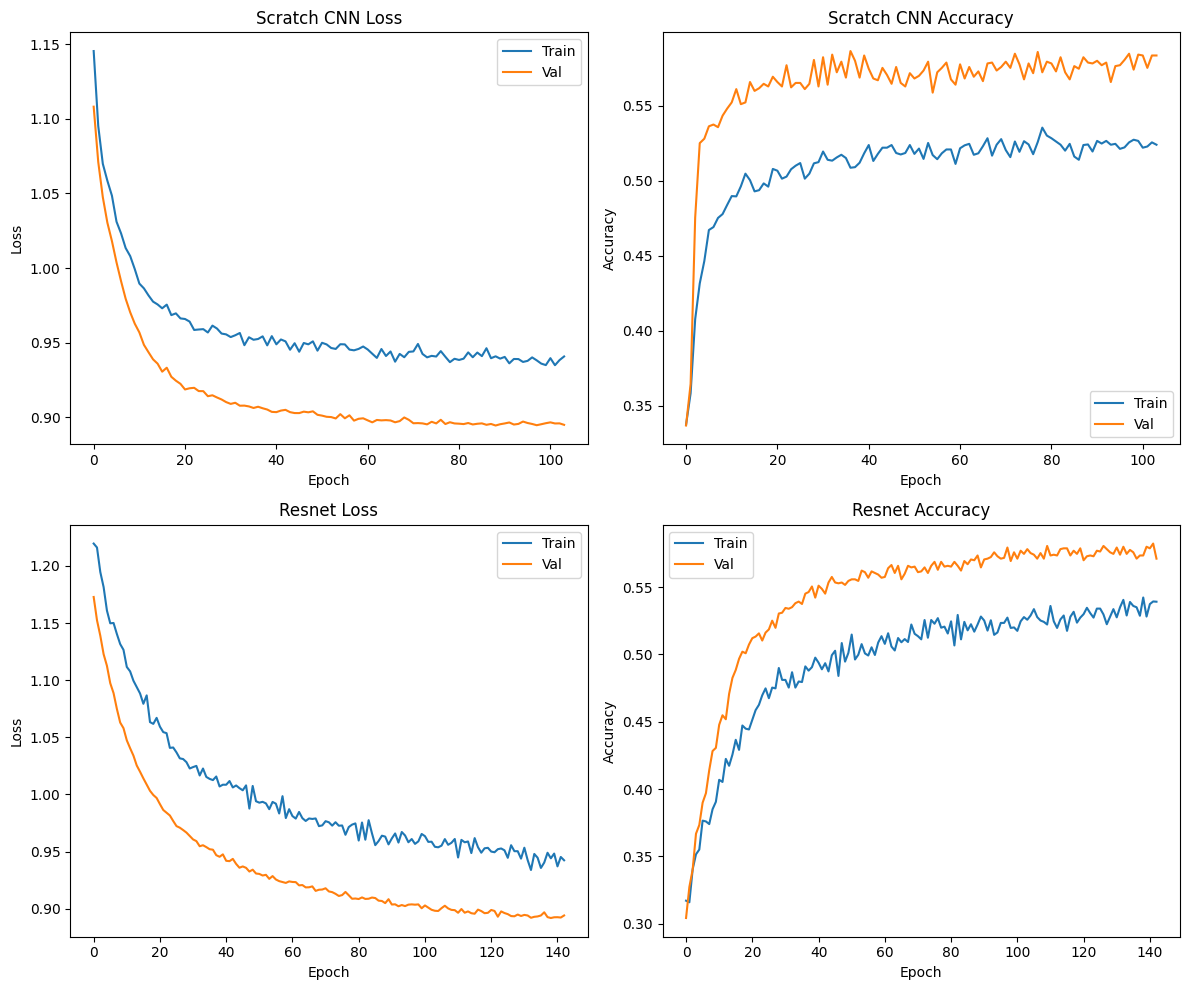

In [9]:
# TRAINING PROGRESS PLOT (from checkpoints, to create the plot again even if the training stopped)

# specific checkpoint:
LOGS_PATH = "/home/hsiegel/deeplearning_finalproj/deeplearning-walkability-cnn/walkability/lightning_logs/version_44448914"

df = pd.read_csv(os.path.join(LOGS_PATH, "metrics.csv"))# Load metrics

# Split train and val rows
train_df = df[df["train_loss"].notna()].copy()
val_df   = df[df["val_loss"].notna()].copy()

# Detect model boundary (epoch resets)
train_df["model"] = (train_df["epoch"].diff() < 0).cumsum()
val_df["model"] = (val_df["epoch"].diff() < 0).cumsum()

# Select models
train1 = train_df[train_df["model"] == 0]
val1 = val_df[val_df["model"] == 0]

train2 = train_df[train_df["model"] == 1]
val2 = val_df[val_df["model"] == 1]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Model 1 Loss
axes[0, 0].plot(train1["epoch"], train1["train_loss"], label="Train")
axes[0, 0].plot(val1["epoch"], val1["val_loss"], label="Val")
axes[0, 0].set_title("Scratch CNN Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Model 1 Accuracy
axes[0, 1].plot(train1["epoch"], train1["train_acc"], label="Train")
axes[0, 1].plot(val1["epoch"], val1["val_acc"], label="Val")
axes[0, 1].set_title("Scratch CNN Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# Model 2 Loss
axes[1, 0].plot(train2["epoch"], train2["train_loss"], label="Train")
axes[1, 0].plot(val2["epoch"], val2["val_loss"], label="Val")
axes[1, 0].set_title("Resnet Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Model 2 Accuracy
axes[1, 1].plot(train2["epoch"], train2["train_acc"], label="Train")
axes[1, 1].plot(val2["epoch"], val2["val_acc"], label="Val")
axes[1, 1].set_title("Resnet Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"training_curves_EVAL.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# EVALUATION:

# scratch is logged first in checkpoints/
scratch_model = CNN.load_from_checkpoint(os.path.join(LOGS_PATH, "checkpoints/Scratch_cnn_weights.ckpt"))
# resnet is logged second
resnet_model  = Pretrained_Resnet.load_from_checkpoint(os.path.join(LOGS_PATH, "checkpoints/Resnet18_weights.ckpt"))

scratch_model.eval()
resnet_model.eval()

Pretrained_Resnet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e

In [12]:
# FUNC TO RUN PREDICTIONS ON TEST SET:
def get_predictions(model, loader):
    all_preds, all_labels, all_images = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            # predict
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds)
            all_labels.append(labels)
            all_images.append(images)
    return (torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy(), torch.cat(all_images)) # preds, labels, data

scratch_preds, true_labels, test_images = get_predictions(scratch_model, test_loader)
resnet_preds, _, _ = get_predictions(resnet_model, test_loader)

In [13]:
# Print accuracy summary table:

scratch_acc = accuracy_score(true_labels, scratch_preds)
resnet_acc  = accuracy_score(true_labels, resnet_preds)

print(f"{'Model':<20} {'Test Accuracy':>15}")
print("-" * 36)
print(f"{'Scratch CNN':<20} {scratch_acc:>15.4f}")
print(f"{'ResNet18':<20} {resnet_acc:>15.4f}")

Model                  Test Accuracy
------------------------------------
Scratch CNN                   0.5523
ResNet18                      0.5535


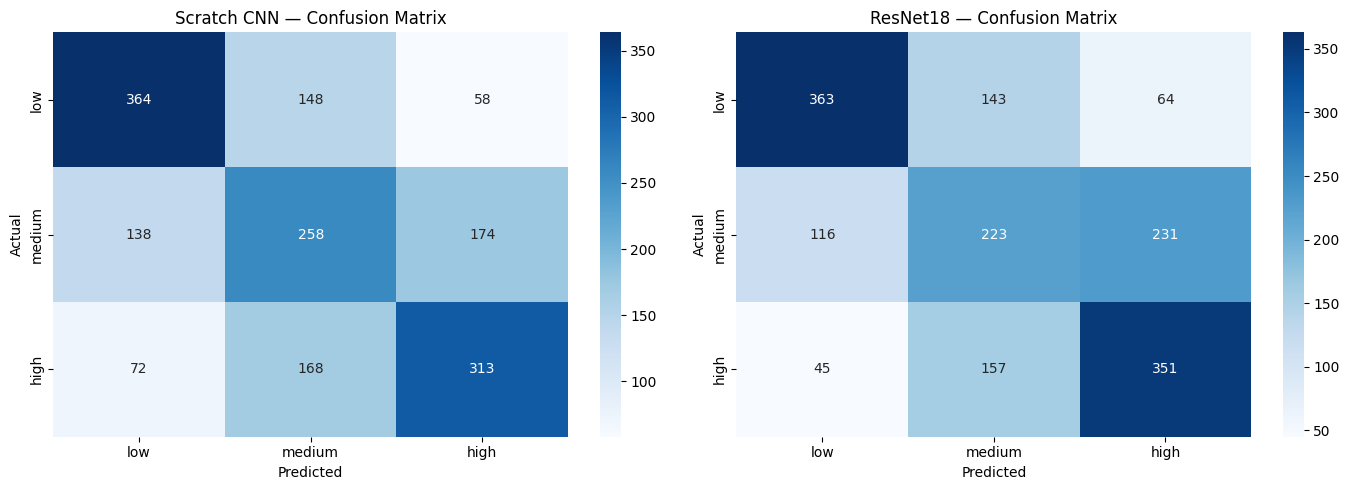

In [14]:
# confusion matrices

from sklearn.metrics import confusion_matrix

class_names = ["low", "medium", "high"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [scratch_preds, resnet_preds],
                             ["Scratch CNN", "ResNet18"]):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()